# Microsoft Planetary Computer Met Office check

In [1]:
import duckdb

con = duckdb.connect()
con.sql("DESCRIBE SELECT * FROM 'output/checks.parquet'")

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ collection         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ item               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ reference_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ has_item           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ num_missing        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [2]:
con.sql("DESCRIBE SELECT * FROM 'output/paths.parquet'")

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ model              │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ reference_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ path               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ collection         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ item               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [3]:
monthly = con.sql("""
    SELECT
        collection,
        date_trunc('month', reference_datetime) AS month,
        SUM(CASE WHEN NOT has_item THEN 1 ELSE 0 END) AS missing,
        SUM(CASE WHEN has_item AND num_missing > 0 THEN 1 ELSE 0 END) AS incomplete,
        SUM(CASE WHEN has_item AND num_missing = 0 THEN 1 ELSE 0 END) AS complete
    FROM 'output/checks.parquet'
    GROUP BY collection, month
    ORDER BY collection, month
""").df()
monthly

,collection,month,missing,incomplete,complete
0,met-office-global-deterministic-height,2024-11-01,2389.0,0.0,4441.0
1,met-office-global-deterministic-height,2024-12-01,3177.0,0.0,5999.0
2,met-office-global-deterministic-height,2025-01-01,3312.0,0.0,5864.0
3,met-office-global-deterministic-height,2025-02-01,2844.0,0.0,5444.0
4,met-office-global-deterministic-height,2025-03-01,3128.0,0.0,6048.0
...,...,...,...,...,...
85,met-office-global-deterministic-whole-atmosphere,2025-12-01,245.0,0.0,8102.0
86,met-office-global-deterministic-whole-atmosphere,2026-01-01,0.0,0.0,9197.0
87,met-office-global-deterministic-whole-atmosphere,2026-02-01,64.0,240.0,8040.0
88,met-office-global-deterministic-whole-atmosphere,2026-03-01,65.0,126.0,9047.0


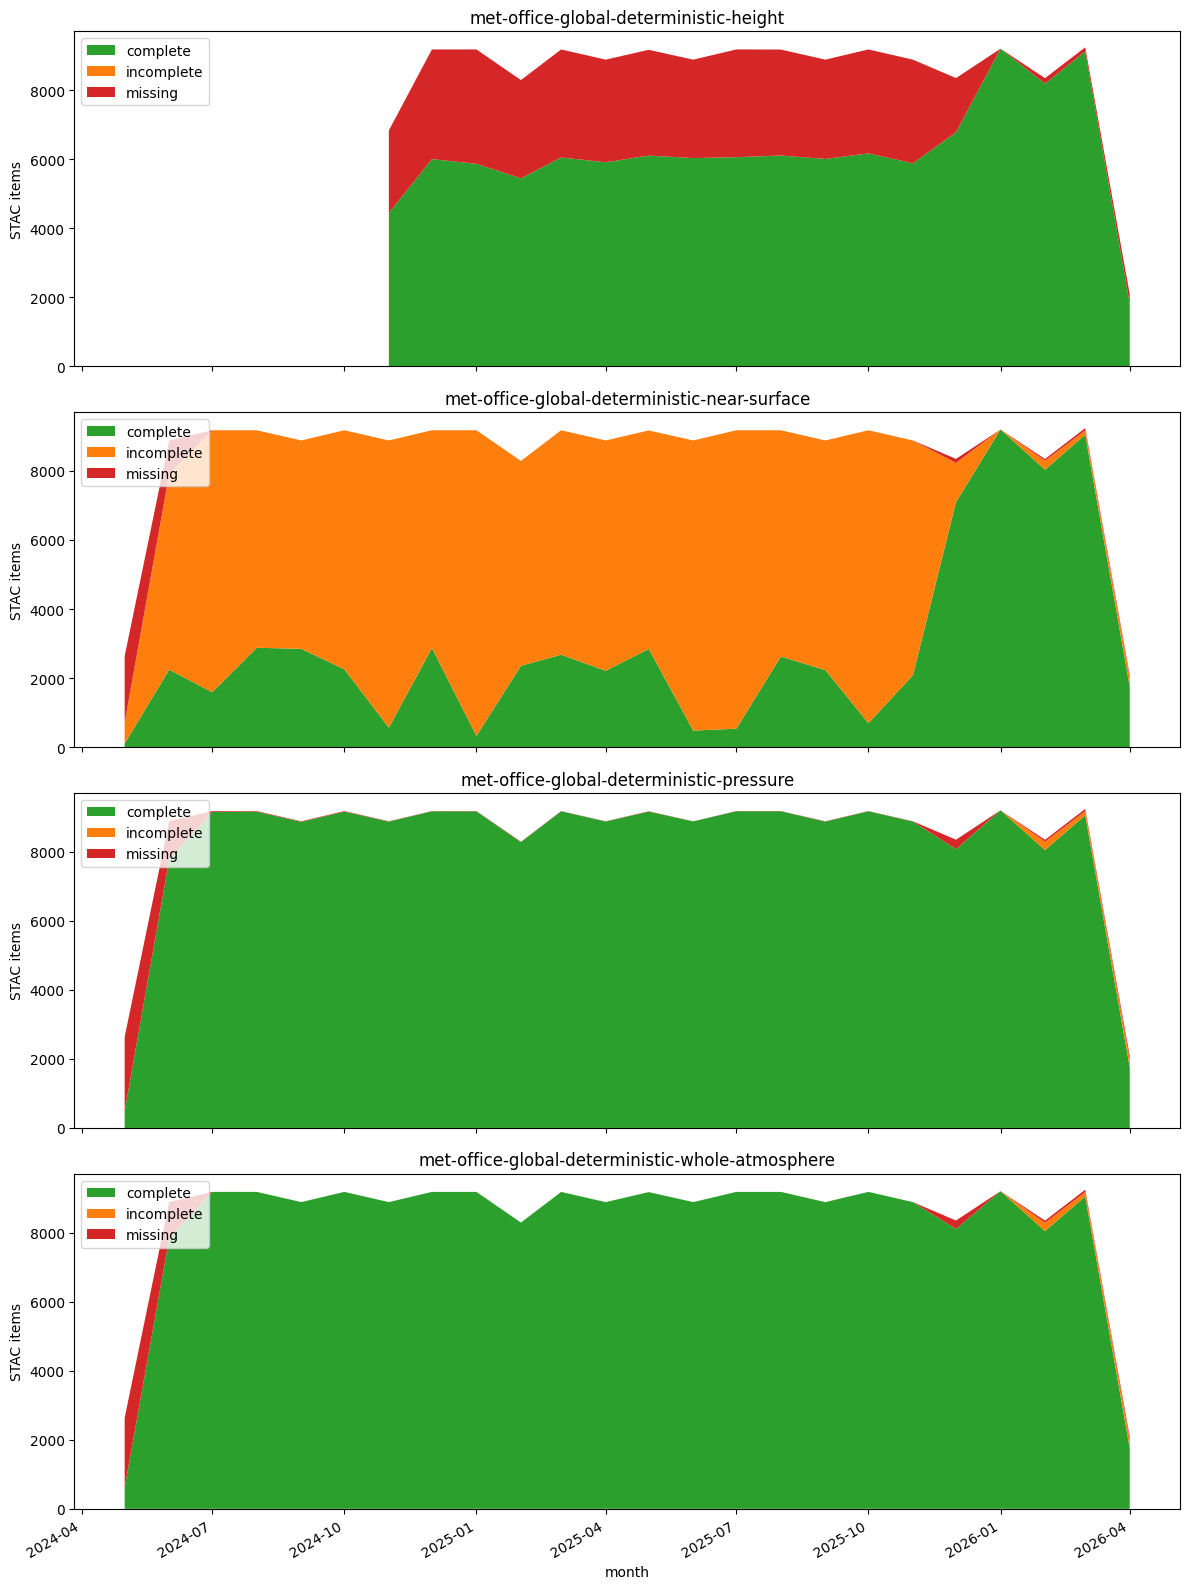

In [4]:
import matplotlib.pyplot as plt

collections = sorted(monthly["collection"].unique())
fig, axes = plt.subplots(len(collections), 1, figsize=(12, 4 * len(collections)), sharex=True)

for ax, collection in zip(axes, collections):
    data = monthly[monthly["collection"] == collection].set_index("month")
    ax.stackplot(
        data.index,
        data["complete"],
        data["incomplete"],
        data["missing"],
        labels=["complete", "incomplete", "missing"],
        colors=["#2ca02c", "#ff7f0e", "#d62728"],
    )
    ax.set_ylabel("STAC items")
    ax.set_title(collection)
    ax.legend(loc="upper left")

axes[-1].set_xlabel("month")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [5]:
con.sql(r"""
    SELECT
        collection,
        regexp_extract(path, '\d+T\d+Z-PT\d+H\d+M-(.+)\.nc$', 1) AS variable,
        COUNT(*) AS missing
    FROM 'output/paths.parquet'
    GROUP BY collection, variable
    ORDER BY collection, missing DESC
""").df()

,collection,variable,missing
0,met-office-global-deterministic-height,cloud_amount_on_height_levels,40931
1,met-office-global-deterministic-near-surface,fog_fraction_at_screen_level,45141
2,met-office-global-deterministic-near-surface,wind_gust_at_10m,44961
3,met-office-global-deterministic-near-surface,precipitation_rate,44945
4,met-office-global-deterministic-near-surface,wind_direction_at_10m,44938
...,...,...,...
66,met-office-global-deterministic-whole-atmosphere,CAPE_most_unstable_below_500hPa,3880
67,met-office-global-deterministic-whole-atmosphere,cloud_amount_of_total_cloud,3879
68,met-office-global-deterministic-whole-atmosphere,cloud_amount_of_low_cloud,3875
69,met-office-global-deterministic-whole-atmosphere,CAPE_mixed_layer_lowest_500m,3873
